<a href="https://colab.research.google.com/github/wwcbyang/DL/blob/main/DL_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 퍼셉트론

### 기본개념
* 퍼셉트론(perceptron): 여러 입력 신호로 부터 하나의 신호를 출력하는 '**알고리즘**'
* y = w1x1 + w2x2
    * w1, w2: 가중치
    * x1, x2: 입력(뉴련, 노드)
    * y: 출력
* y = 0 if (w1x1 + w2x2 <= θ) else 1
    * θ: 임계값
* y = 0 if (w1x1 + w2x2 + b <= 0) else 1
    * b: 편향(bias)

### 논리회로 with 퍼셉트론
* AND, NAND, OR 게이트를 퍼셉트론으로 구현

In [ ]:
import numpy as np

In [ ]:
# AND 게이트
def AND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.7
    tmp = np.sum(x * w) + b
    if tmp <= 0:
        return 0
    else:
        return 1

In [ ]:
# AND 게이트 테스트
print(AND(0, 0)) # 0
print(AND(1, 0)) # expect: 0
print(AND(0, 1)) # expect: 0
print(AND(1, 1)) # expect: 1

0
0
0
1


In [ ]:
# NAND 게이트
def NAND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([-0.5, -0.5])
    b = 0.7
    tmp = np.sum(x * w) + b
    if tmp <= 0:
        return 0
    else:
        return 1

In [ ]:
print(NAND(0, 0)) # expect: 1
print(NAND(1, 0)) # expect: 1
print(NAND(0, 1)) # expect: 1
print(NAND(1, 1)) # expect: 0

1
1
1
0


In [ ]:
# OR 게이트
def OR(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.3
    tmp = np.sum(x * w) + b
    if tmp <= 0:
        return 0
    else:
        return 1

In [ ]:
print(OR(0, 0)) # expect: 0
print(OR(1, 0)) # expect: 1
print(OR(0, 1)) # expect: 1
print(OR(1, 1)) # expect: 1

0
1
1
1


### 퍼셉트론의 한계, XOR(베타적 논리합)
* 직선 하나만으로는 XOR의 논리 분리 영역(0 or 1)을 만드는 것이 불가능하다.
* 직선이라는 제약이 없다면 가능하다.(비선형)
* 퍼셉트론의 한계를 '다층 퍼셉트론', 층을 쌓아서 해결할 수 있다.
* XOR을 AND, OR, NAND로 표현할 수 있다.
    * 층을 쌓아서 '비선형'을 표현할 수 있다! -> 다층 퍼셉트론

In [ ]:
# XOR 구현 with 이미 만든 게이트
def XOR(x1, x2):
    s1 = NAND(x1, x2)
    s2 = OR(x1, x2)
    y = AND(s1, s2)
    return y

In [ ]:
print(XOR(0, 0)) # expect: 0
print(XOR(1, 0)) # expect: 1
print(XOR(0, 1)) # expect: 1
print(XOR(1, 1)) # expect: 0

0
1
1
0


## 신경망

### 퍼셉트론에서 신경망 관점으로
* 퍼셉트론은 아래와 같이 식을 구성했다.
    * y = 0 if (b + w1x1 + w2x2) <= 0
    * y = 1 if (b + w1x1 + w2x2) > 0
    * w1, w2는 가중치로, 각 신호의 '영향력'
    * b는 편향으로, 출력함수의 활성화정도를 제어했다.
* 이제, b 또한 상수 1노드의 가중치로 생각하고, 아래와 같이 생각해보자.
    * y = h(b*1 + w1x1 + w2x2)
    * h(x) = 0 if x <= 0 else 1
* 좀만 더 바꿔보자,
    * a = h(b*1 + w1x1 + w2x2)
    * y = h(a)
        * h(x) = 0 if x <= 0 else 1
        * ---> h(x)가 '입력신호를 출력신호로 변환'하는 역할을 한다.
        * 위와 같은 함수를 '**활성화 함수**'라고 한다.






### 활성화 함수(Activation function)
* 다양한 활성화 함수가 있지만, 3가지 활성화 함수를 먼저 구현
    * 계단 함수(step function)
    * 시그모이드 함수(sigmoid function)
    * ReLU 함수(Rectified Linear Unit)

#### 계단 함수
* 계단 함수: 계단 처럼 생긴 함수

In [ ]:
### 계단함수
def step_function(x):
    y = x > 0
    return y.astype(int)

In [ ]:
print(step_function(np.array([1])))
print(step_function(np.array([1, 2])))
print(step_function(np.array([-1, 0, 1])))

[1]
[1 1]
[0 0 1]


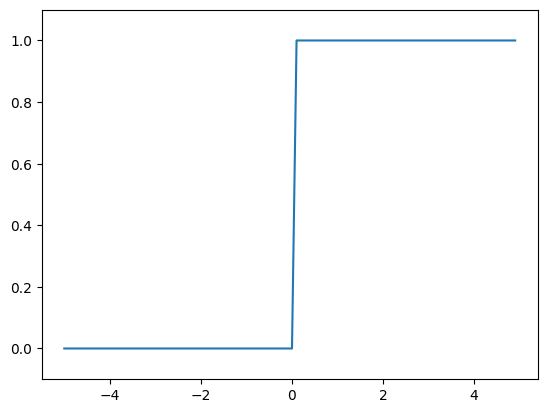

In [ ]:
### 계단함수를 함수를 그려보자
import numpy as np
import matplotlib.pyplot as plt

def step_func(x):
    return np.array(x > 0, dtype=int)

x = np.arange(-5.0, 5.0, 0.1) # numpy.ndarray
y = step_func(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

#### 시그모이드 함수
* 시그모이드 함수: sig + moid, S자로 생긴 함수라는 뜻

In [ ]:
import numpy as np
### 시그모이드 함수
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
print(sigmoid(1))
print(sigmoid(np.array([-1, 1, 2]))) # broadcasting
print(type(sigmoid(1)))
print(type(sigmoid(np.array([-1, 1, 2]))))

0.7310585786300049
[0.26894142 0.73105858 0.88079708]
<class 'numpy.float64'>
<class 'numpy.ndarray'>


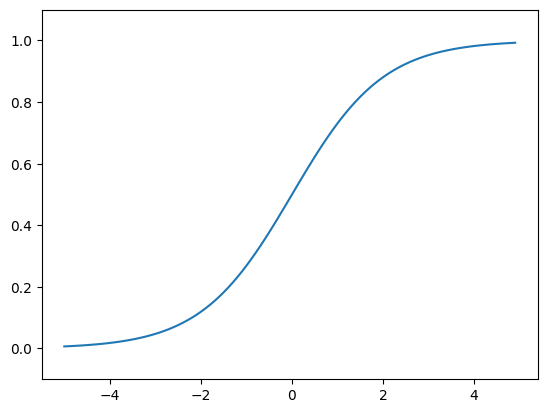

In [ ]:
import numpy as np
import matplotlib.pylab as plt

### 시그모이드 함수 그리기
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)

plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

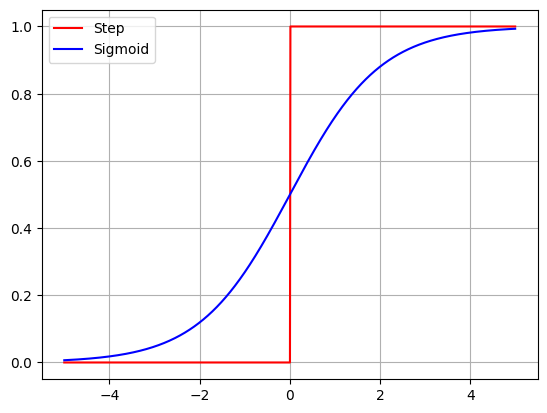

In [ ]:
### 두 함수 비교
import numpy as np
import matplotlib.pyplot as plt

def step_function(x):
    return np.array(x > 0, dtype=int)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.arange(-5.0, 5.0, 0.01)
y_step = step_function(x)
y_sig = sigmoid(x)

plt.plot(x, y_step, label="Step", color="red")
plt.plot(x, y_sig, label="Sigmoid", color="blue")
plt.grid()
plt.legend()
plt.show()

#### ReLU 함수
* Rectified Linear Unit: 0 이하에선 0, 이상일 땐 x, 전자기학에서 따온 '정류'

In [ ]:
import numpy as np

### ReLU
def relu(x):
    return np.maximum(0, x)

In [ ]:
print(relu(1))
print(relu(np.array([-1, 0, 0,1, 1])))

1
[0 0 0 1 1]


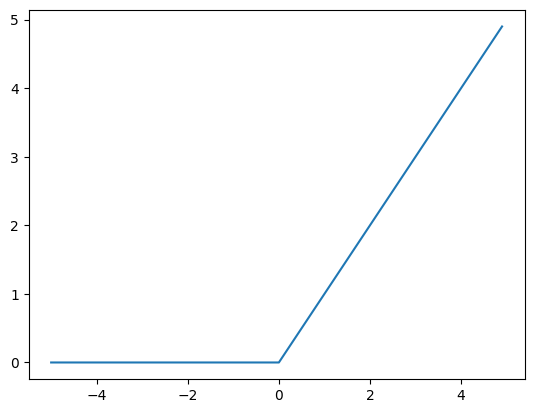

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
### 그려보자
x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)

plt.plot(x, y)
plt.show()

#### 동시에 그려보자

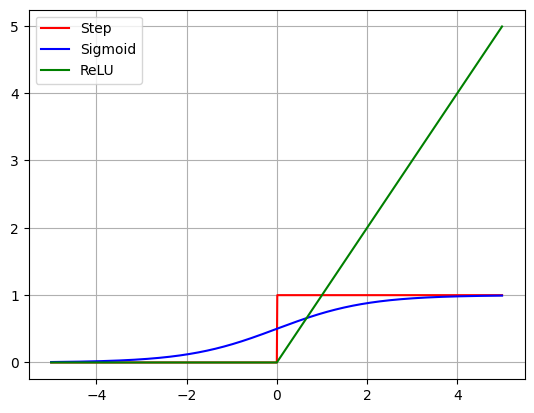

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def step_function(x):
    return np.array(x > 0, dtype=int)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.01)
y_step = step_function(x)
y_sig = sigmoid(x)
y_relu = relu(x)

plt.plot(x, y_step, label="Step", color="red")
plt.plot(x, y_sig, label="Sigmoid", color="blue")
plt.plot(x, y_relu, label="ReLU", color="green")
plt.grid()
plt.legend()
plt.show()

### 다차원 배열의 계산


#### 차원을 뭐라고 정의하나
* 개인적으로 차원을 다음과 같이 정의하고 싶다: 숫자를 '어떻게' 늘어놓았는가에서, 어떻게.

In [10]:
### 차원 check
import numpy as np

# 1차원 배열
A = np.array([1, 2, 3, 4])
print(type(A))
# 차원 확인: np.ndim()
print(np.ndim(A))  # 1
# 형상 확인: shape(인스턴스 변수)
print(A.shape) # (4,) 1차원. 다차원과 형태를 맞추기 위해서 '튜플'로 나옴

# 2차원 배열
B = np.array([[1, 2], [3, 4], [5, 6]])
print(np.ndim(B)) # 2
print(B.shape) # (3, 2)

<class 'numpy.ndarray'>
1
(4,)
2
(3, 2)


#### 행렬의 곱셈(내적, dot product)
* 행렬: 다차원 배열 중에 2차원 배열
    * 행: row(가로)
    * 열: column(세로)
* 행렬 곱셈의 조건
    * np.dot(A, B)가 수행되기 위해선, A의 열의 수와 B의 행의 수가 동일해야한다.
    * 예를 들어, A가 3x2행렬이고, B가 2x2행렬이면 행렬의 곱셈 가능
    * 예를 들어, A가 3x2행렬이고, B가 3x3행렬이면 행렬의 곱셈 불가능
    * 3x2 행렬과 2x2행렬이 곱해지면, 3x2행렬이됨.(첫번째 행렬의 행, 두번째 행렬의 열)

In [12]:
### 행렬의 곱셈
import numpy as np

A = np.array([[1, 2], [3, 4], [5, 6]]) # 3x2
B = np.array([[1, 2], [3, 4]]) # 2x2
C = np.dot(A, B)
print(C.shape)
print(C)

(3, 2)
[[ 7 10]
 [15 22]
 [23 34]]


In [13]:
### 실패 예시
import numpy as np

A = np.array([[1, 2], [3, 4], [5, 6]]) # 3x2
B = np.array([[1, 2], [3, 4], [10, 5]]) # 3x3
C = np.dot(A, B)
print(C.shape) # ValueError: shapes (3,2) and (3,2) not aligned: 2 (dim 1) != 3 (dim 0)
print(C)

ValueError: shapes (3,2) and (3,2) not aligned: 2 (dim 1) != 3 (dim 0)

In [21]:
### 추가 벡터 계산
import numpy as np

A = np.array([[1, 2], [3, 4], [5, 6]]) # 3x2
B = np.array([1, 2]) # (2,)
print(B.shape)
print(np.dot(A, B))

C = np.array([[1], [2]]) # (2, 1)
print(C.shape)
print(np.dot(A, C))

# 아래는 안됨. 3x2 (3,)
D = np.array([1, 2, 3])
print(D.shape)
print(np.dot(A, D))

(2,)
[ 5 11 17]
(2, 1)
[[ 5]
 [11]
 [17]]
(3,)


ValueError: shapes (3,2) and (3,) not aligned: 2 (dim 1) != 3 (dim 0)

#### 신경망에서의 활용
* x1, x2와 같은 입력노드의 집합을 X라고 하자, X=[x1, x2]
* w1, w2, w3, w4, w5, w6와 같은 가중치 집합을 W라고 하자, W=[w1, w2, w3, w4, w5, w6]
* 다음 층의 노드를 y1, y2, y3라고 하자 집합을 Y라고 하자, Y=[y1, y2, y3]
* 아래와 같이 표현가능하다.
    => np(X, W) = Y
* 행렬의 곱으로 한꺼번에 계산해주는 기능!!!! 뽷!!!

In [28]:
### 신경망에서의 활용
X = np.array([1, 2])
print(X.shape) # 가로세로 구분을 하지 않음
W = np.array([[1, 3, 5], [2, 4, 6]])
print(W.shape)
Y = np.dot(X, W)
print(Y.shape)
print(Y)


(2,)
(2, 3)
(3,)
[ 5 11 17]
